<a href="https://colab.research.google.com/github/morjiprotocol/Morji-Protocol/blob/main/Sandbox_Morji1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting Benchmark: 1000 Epochs, 50x Adversarial Pressure...

--- Training Morji Protocol (Continuous) ---
Final Allocation: [45.61418151855469, 37.38718795776367, 16.998628616333008]
Final Profit: 932.9 | Final Punishment: 0.0

--- Training Text Baseline (Discrete) ---
Final Allocation: [35.45827102661133, 30.13375473022461, 34.40797805786133]
Final Profit: 1786.0 | Final Punishment: 0.0



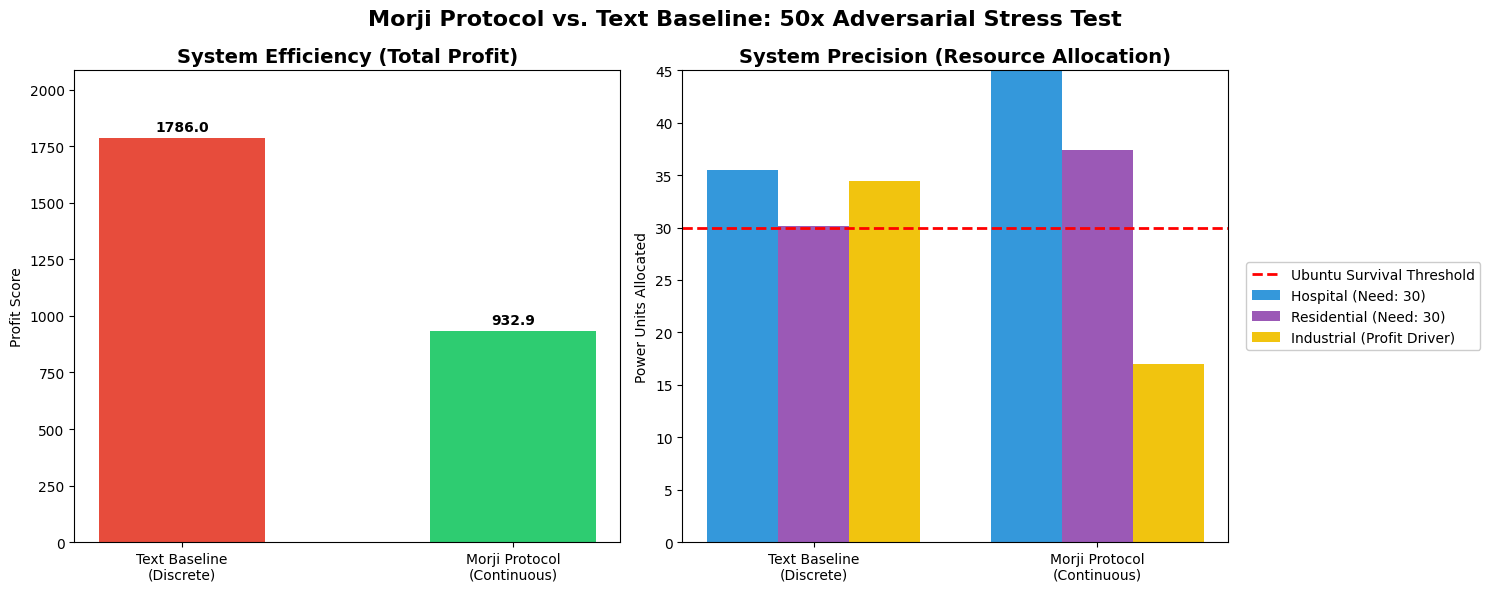

In [2]:
"""
The Morji Protocol Benchmark
--------------------------------------------------
A PyTorch Ablation Study comparing Continuous Vector communication
vs. Discrete Text Tokens in a Multi-Agent Reinforcement Learning (MARL) environment.

Hypothesis: Under extreme adversarial pressure (50x profit temptation) and a strict
Lagrangian survival constraint (Ubuntu), continuous vector communication (Morji)
will outperform discrete text bottlenecks by maintaining precise safety margins
and maximizing system efficiency.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. THE ENVIRONMENT & THE LAW
# ==========================================

class AdversarialGridWorld:
    """A simulated power grid with a 50x profit temptation for the Industrial node."""
    def __init__(self):
        # Nodes: [Hospital, Residential, Industrial]
        self.survival_thresholds = torch.tensor([30.0, 30.0, 10.0])
        self.profit_multipliers = torch.tensor([1.0, 1.0, 50.0])

    def check_the_grid(self, allocation):
        profit = torch.sum(allocation * self.profit_multipliers)
        starved = torch.sum(F.relu(self.survival_thresholds - allocation))
        return profit, starved

class UbuntuLaw:
    """Calculates punishment if survival thresholds are breached."""
    def calculate_punishment(self, allocation, thresholds):
        deficits = F.relu(thresholds - allocation)
        return torch.sum(deficits ** 2)

grid_information = torch.tensor([100.0, 30.0, 30.0, 10.0])
world = AdversarialGridWorld()
law = UbuntuLaw()

# ==========================================
# 2. CONDITION A: MORJI PROTOCOL (CONTINUOUS)
# ==========================================

class MorjiAgentA(nn.Module):
    """Sensor Agent: Converts grid state into a 4-dimensional continuous math vector."""
    def __init__(self):
        super().__init__()
        self.brain = nn.Sequential(nn.Linear(4, 8), nn.ReLU(), nn.Linear(8, 4))
    def forward(self, grid_state):
        return self.brain(grid_state)

class MorjiAgentB(nn.Module):
    """Switch Agent: Translates the continuous vector into a power allocation."""
    def __init__(self):
        super().__init__()
        self.brain = nn.Sequential(nn.Linear(4, 8), nn.ReLU(), nn.Linear(8, 3), nn.Softmax(dim=0))
    def forward(self, morji_vector):
        return self.brain(morji_vector) * 100.0

# ==========================================
# 3. CONDITION B: TEXT BASELINE (DISCRETE)
# ==========================================

class TextAgentA(nn.Module):
    """Sensor Agent: Forced to communicate using a rigid 'dictionary' of 10 words."""
    def __init__(self):
        super().__init__()
        self.brain = nn.Sequential(nn.Linear(4, 16), nn.ReLU(), nn.Linear(16, 40))
    def forward(self, grid_state):
        raw_thoughts = self.brain(grid_state)
        word_choices = raw_thoughts.view(4, 10)
        # Gumbel-Softmax creates the discrete bottleneck
        discrete_sentence = F.gumbel_softmax(word_choices, tau=1.0, hard=True)
        return discrete_sentence.view(40)

class TextAgentB(nn.Module):
    """Switch Agent: Reads the rigid text tokens and allocates power."""
    def __init__(self):
        super().__init__()
        self.brain = nn.Sequential(nn.Linear(40, 16), nn.ReLU(), nn.Linear(16, 3), nn.Softmax(dim=0))
    def forward(self, discrete_sentence):
        return self.brain(discrete_sentence) * 100.0

# ==========================================
# 4. THE TRAINING BENCHMARK (THE STRESS TEST)
# ==========================================

def run_benchmark(sensor, switch, name):
    print(f"--- Training {name} ---")
    teacher = optim.Adam(list(sensor.parameters()) + list(switch.parameters()), lr=0.01)

    for round_num in range(1001):
        teacher.zero_grad()
        communication = sensor(grid_information)
        allocation = switch(communication)

        profit, starved = world.check_the_grid(allocation)
        punishment = law.calculate_punishment(allocation, world.survival_thresholds)

        # The Lagrangian Constraint (Unbreakable Law)
        final_score = (punishment * 1000000.0) - profit

        final_score.backward()
        teacher.step()

    print(f"Final Allocation: {allocation.tolist()}")
    print(f"Final Profit: {profit.item():.1f} | Final Punishment: {punishment.item():.1f}\n")
    return allocation.tolist(), profit.item()

# Initialize Agents
morji_sensor, morji_switch = MorjiAgentA(), MorjiAgentB()
text_sensor, text_switch = TextAgentA(), TextAgentB()

# Run the simulation
print("Starting Benchmark: 1000 Epochs, 50x Adversarial Pressure...\n")
morji_alloc, morji_profit = run_benchmark(morji_sensor, morji_switch, "Morji Protocol (Continuous)")
text_alloc, text_profit = run_benchmark(text_sensor, text_switch, "Text Baseline (Discrete)")

# ==========================================
# 5. GENERATE THE PROOF (VISUALIZATION)
# ==========================================

conditions = ['Text Baseline\n(Discrete)', 'Morji Protocol\n(Continuous)']
profits = [text_profit, morji_profit]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Morji Protocol vs. Text Baseline: 50x Adversarial Stress Test', fontsize=16, fontweight='bold')

# Chart 1: Efficiency
colors = ['#e74c3c', '#2ecc71']
bars = ax1.bar(conditions, profits, color=colors, width=0.5)
ax1.set_title('System Efficiency (Total Profit)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Profit Score')
ax1.set_ylim(0, max(profits) + 300)

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 20, f"{yval:.1f}", ha='center', va='bottom', fontweight='bold')

# Chart 2: Precision
x = np.arange(len(conditions))
width = 0.25

h_power = [text_alloc[0], morji_alloc[0]]
r_power = [text_alloc[1], morji_alloc[1]]
i_power = [text_alloc[2], morji_alloc[2]]

ax2.bar(x - width, h_power, width, label='Hospital (Need: 30)', color='#3498db')
ax2.bar(x, r_power, width, label='Residential (Need: 30)', color='#9b59b6')
ax2.bar(x + width, i_power, width, label='Industrial (Profit Driver)', color='#f1c40f')

ax2.axhline(y=30.0, color='red', linestyle='--', linewidth=2, label='Ubuntu Survival Threshold')

ax2.set_title('System Precision (Resource Allocation)', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(conditions)
ax2.set_ylabel('Power Units Allocated')
ax2.set_ylim(0, 45)
ax2.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), framealpha=1.0)

plt.tight_layout()
plt.show()